In [100]:
import numpy as np #1.1
arr = np.linspace(0, 20, 100)
mean = np.mean(arr)
median = np.median(arr)
std_dev = np.std(arr)
variance = np.var(arr)

print("Array:", arr)
print(f"Array shape: {arr.shape}")
print(f"\nStatistical Measures:")
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")
print(f"Variance: {variance}")

Array: [ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.3636

In [101]:
import numpy as np#1.2

arr1 = np.array(
    [i for i in range(1, 37)])
print(arr1)
arr2 = arr1.reshape(4, 9)

print(f"Array:\n{arr2}")

print()
arr_flat = arr2.flatten()
print(f"Array: {arr_flat}")





[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
Array:
[[ 1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18]
 [19 20 21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34 35 36]]

Array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]


In [102]:
import seaborn as sns#2.1
import pandas as pd


df = sns.load_dataset('titanic')
print("First 5 rows:")
print(df.head())
print()


print("Dataset Info:")
print(df.info())
print()


print("Statistical Summary:")
print(df.describe())

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   

In [103]:
import seaborn as sns#2.2
import pandas as pd
import numpy as np
df = sns.load_dataset('titanic')
print("Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)
print()

print("Filling missing 'age' values with median grouped by pclass...")
df['age'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)
print(f"Missing values in 'age' after treatment: {df['age'].isnull().sum()}")
print()
print("Filling missing 'embarked' values with mode...")
embarked_mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(embarked_mode)
print(f"Missing values in 'embarked' after treatment: {df['embarked'].isnull().sum()}")
print()
print("Dropping 'deck' column...")
print(f"Missing values in 'deck': {df['deck'].isnull().sum()} ({df['deck'].isnull().sum()/len(df)*100:.2f}%)")
print("Reason for dropping: 'deck' has 77.2% missing values, making it unreliable for analysis")
df = df.drop('deck', axis=1)
print(f"Columns after dropping 'deck': {df.columns.tolist()}")
print()
print("Verification - Remaining nulls in dataset:")
print(df.isnull().sum())
print(f"\nTotal null values remaining: {df.isnull().sum().sum()}")

Missing Values Analysis:
                  Column  Missing_Count  Missing_Percentage
deck                deck            688               77.22
age                  age            177               19.87
embarked        embarked              2                0.22
embark_town  embark_town              2                0.22

Filling missing 'age' values with median grouped by pclass...
Missing values in 'age' after treatment: 0

Filling missing 'embarked' values with mode...
Missing values in 'embarked' after treatment: 0

Dropping 'deck' column...
Missing values in 'deck': 688 (77.22%)
Reason for dropping: 'deck' has 77.2% missing values, making it unreliable for analysis
Columns after dropping 'deck': ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Verification - Remaining nulls in dataset:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare

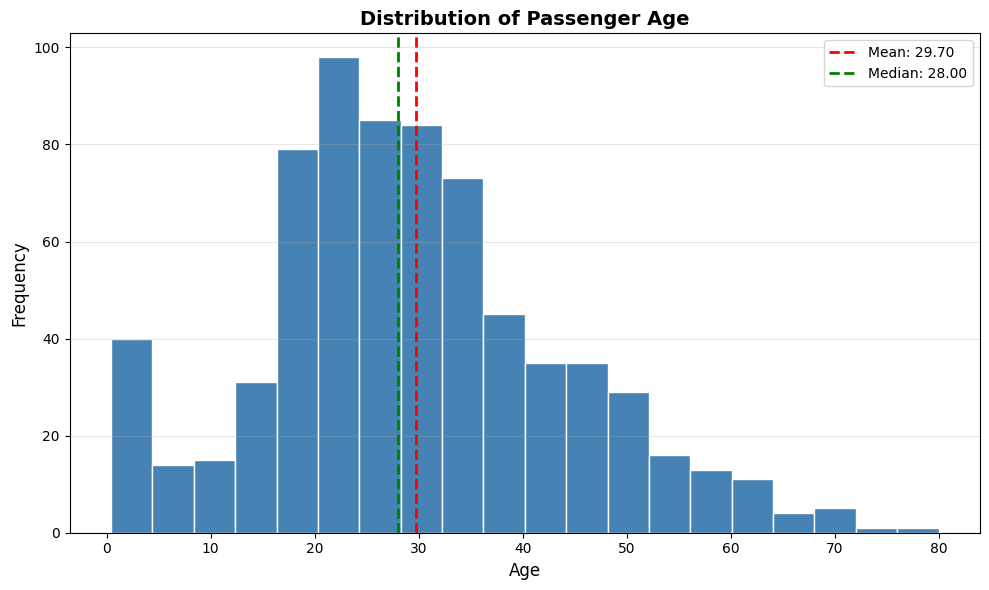

In [104]:
import matplotlib.pyplot as plt #3.1
import seaborn as sns
df = sns.load_dataset('titanic')
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
age_mean = df['age'].mean()
age_median = df['age'].median()
plt.axvline(age_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {age_mean:.2f}')
plt.axvline(age_median, color='green', linestyle='--', linewidth=2, label=f'Median: {age_median:.2f}')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

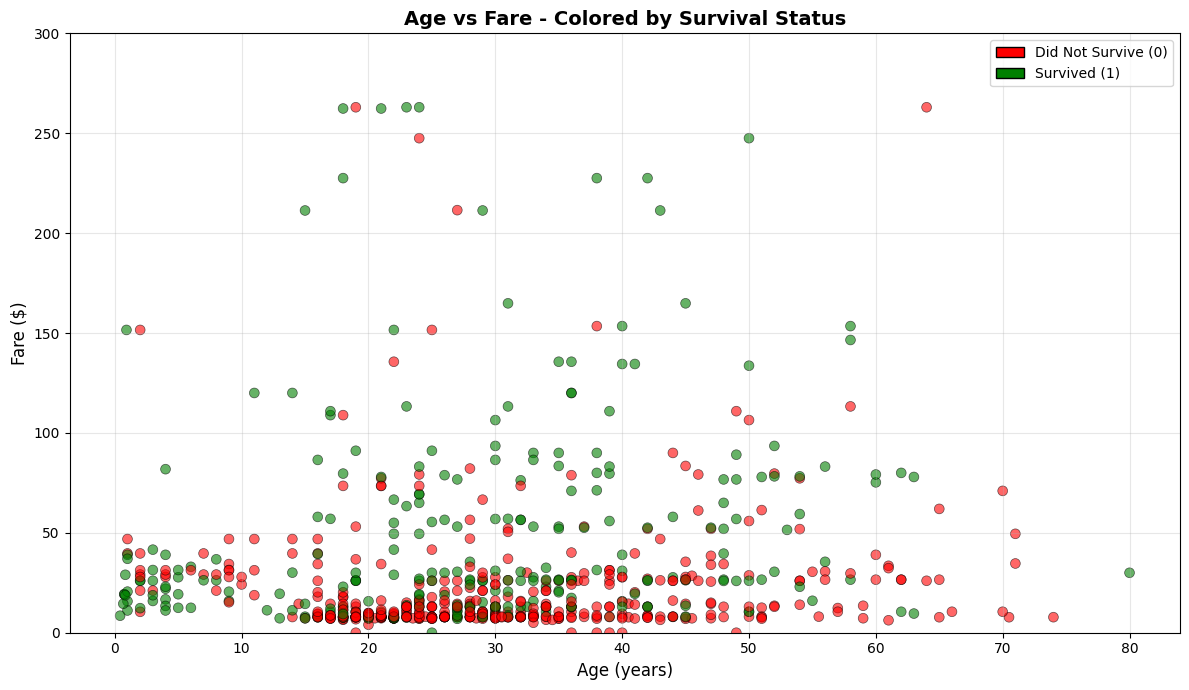

Note: Y-axis is capped at 300 to remove extreme outliers for better readability.
Original max fare: $512.33
Outliers removed from view: 3 data points


In [105]:
import matplotlib.pyplot as plt#3.2
import seaborn as sns
df = sns.load_dataset('titanic')
fig, ax = plt.subplots(figsize=(12, 7))
colors = df['survived'].map({0: 'red', 1: 'green'})
ax.scatter(df['age'], df['fare'], c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_ylim(0, 300)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare ($)', fontsize=12)
ax.set_title('Age vs Fare - Colored by Survival Status', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='black', label='Did Not Survive (0)'),
                   Patch(facecolor='green', edgecolor='black', label='Survived (1)')]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Note: Y-axis is capped at 300 to remove extreme outliers for better readability.")
print(f"Original max fare: ${df['fare'].max():.2f}")
print(f"Outliers removed from view: {(df['fare'] > 300).sum()} data points")

Shape: (200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Summary Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


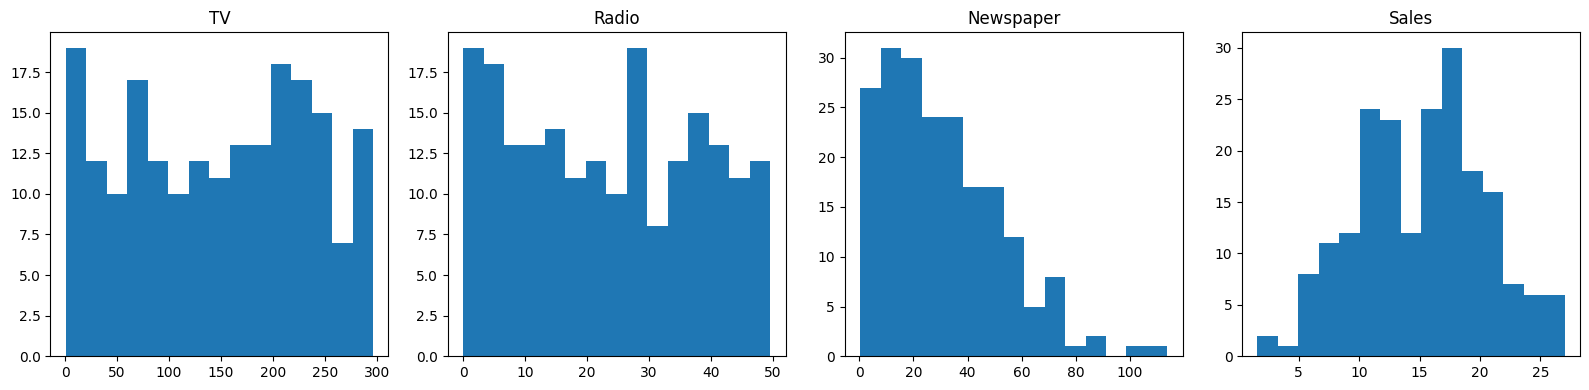

In [106]:
import pandas as pd#4.1
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("advertising.csv")

# 1. Basic information
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# 2. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 3. Histograms (1x4 subplot)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=15)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


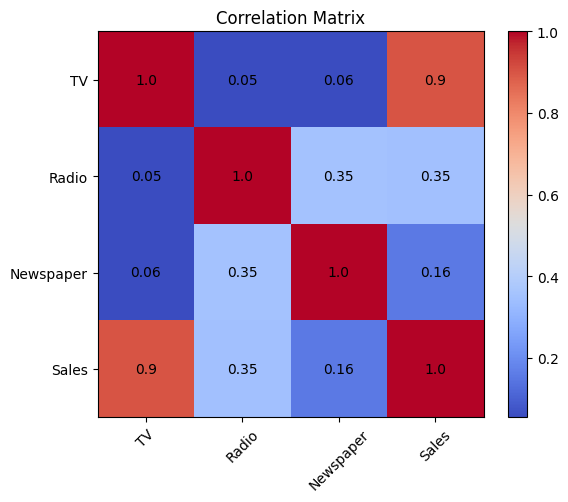

In [107]:
import numpy as np#4.2
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=45)

plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)

# Annotate values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i,
                 round(corr_matrix.iloc[i, j], 2),
                 ha='center',
                 va='center')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [108]:
import numpy as np#5.1

X = df["TV"].values
y = df["Sales"].values

X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

m = np.sum((X_train - x_mean) * (y_train - y_mean)) / np.sum((X_train - x_mean)**2)

b = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (b):", b)

y_pred = m * X_test + b

mse = np.mean((y_test - y_pred)**2)

print("Test MSE:", mse)

Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353
Test MSE: 5.459799471482253


In [109]:
from sklearn.model_selection import train_test_split#5.2
from sklearn.linear_model import LinearRegression

X = df[["TV"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.0554829439314632
Intercept: 7.007108428241848


In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score#5.3
import numpy as np

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("TRAIN METRICS")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTEST METRICS")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

TRAIN METRICS
MAE : 1.8005092256620792
MSE : 4.998442356450173
RMSE: 2.235719650683013
R²  : 0.8134866044709264

TEST METRICS
MAE : 1.9502948931650088
MSE : 6.101072906773963
RMSE: 2.470035001123256
R²  : 0.802561303423698


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

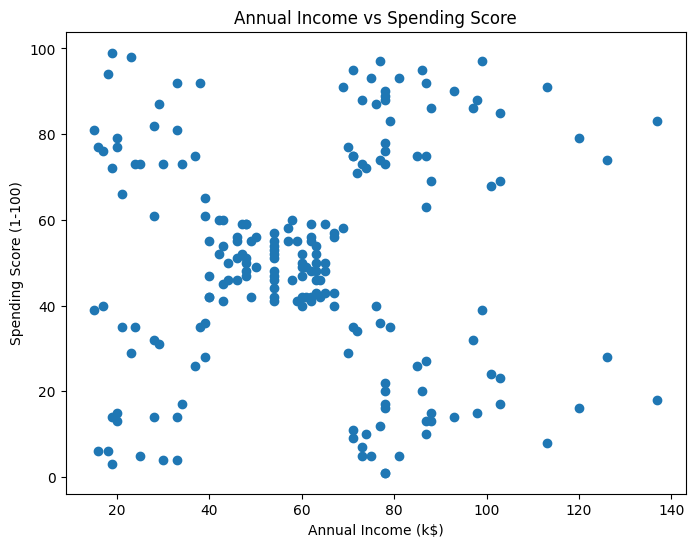

In [111]:
import pandas as pd#6.1

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print(df.info())

print(df.describe())
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043
         Customer Count  Mean Annual Income  Mean Spending Score
Cluster                                                         
0                    81           55.296296            49.518519
1     

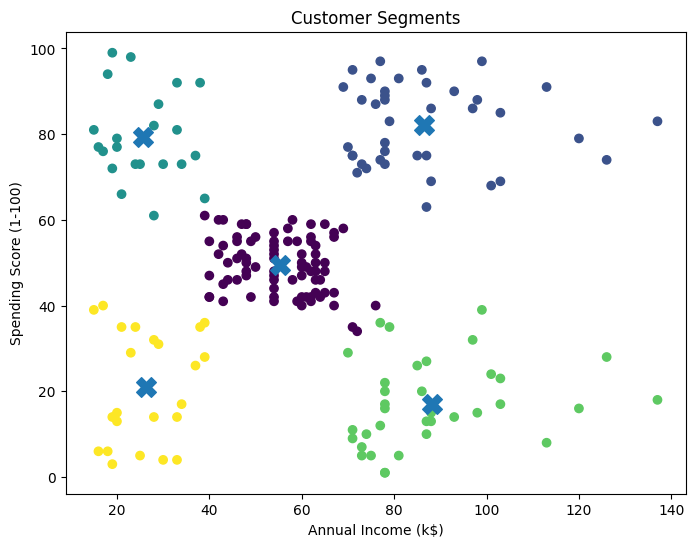

In [112]:
from sklearn.cluster import KMeans#6.2

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

print(df.head())
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print(centroids)
cluster_summary = df.groupby("Cluster").agg({
    "CustomerID": "count",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
})

cluster_summary.columns = [
    "Customer Count",
    "Mean Annual Income",
    "Mean Spending Score"
]

print(cluster_summary)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


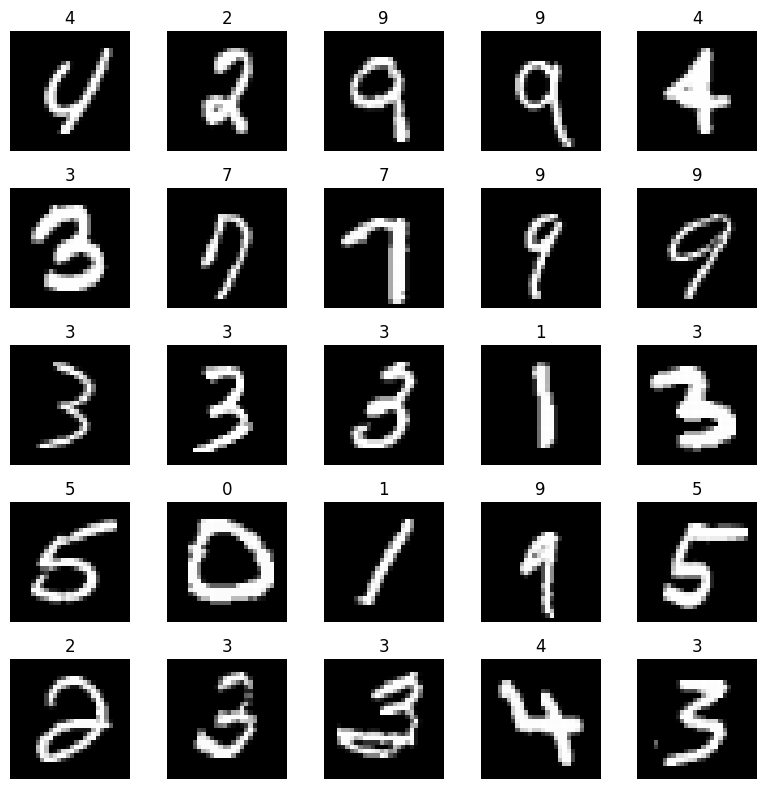

In [113]:
from tensorflow.keras.datasets import mnist#7.1
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0
import matplotlib.pyplot as plt

indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(y_train[idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential#7.2
from tensorflow.keras.layers import Flatten, Dense

ffnn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ffnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ffnn.summary()
history_ffnn = ffnn.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)
plt.figure(figsize=(8,5))
plt.plot(history_ffnn.history["accuracy"])
plt.plot(history_ffnn.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("Feedforward NN Accuracy")
plt.show()
plt.figure(figsize=(8,5))
plt.plot(history_ffnn.history["loss"])
plt.plot(history_ffnn.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("Feedforward NN Loss")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9221 - loss: 0.2611 - val_accuracy: 0.9541 - val_loss: 0.1514
Epoch 2/15


In [ ]:
test_loss_ffnn, test_acc_ffnn = ffnn.evaluate(X_test, y_test)#7.3

print("Test Loss:", test_loss_ffnn)
print("Test Accuracy:", test_acc_ffnn)
from sklearn.metrics import confusion_matrix

y_pred = np.argmax(ffnn.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,3))

for i in range(3):
    idx = misclassified[i]

    plt.subplot(1,3,i+1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
    plt.axis("off")

plt.show()

In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)#7.4
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()
history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)
test_loss_cnn, test_acc_cnn = cnn.evaluate(
    X_test_cnn,
    y_test
)

print("Test Accuracy:", test_acc_cnn)
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Feedforward NN", "CNN"],
    "Parameters": [109386, cnn.count_params()],
    "Train Acc": [
        history_ffnn.history["accuracy"][-1],
        history_cnn.history["accuracy"][-1]
    ],
    "Val Acc": [
        history_ffnn.history["val_accuracy"][-1],
        history_cnn.history["val_accuracy"][-1]
    ],
    "Test Acc": [
        test_acc_ffnn,
        test_acc_cnn
    ],
    "Epochs": [15, 10]
})

print(comparison)